# Sex-based Algorithmic Fairness Audit of Credit Risk ADS

In [ ]:
# Relevant pip installs
!pip install pandas
!pip install numpy
!pip install scikit-learn
!pip install lightgbm
!pip install fairlearn
!pip install shap
!pip install dowhy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 39.9 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.1/403.1 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.3/204.3 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 37.8 MB/s eta 0:00:00
  Attempting uninstall: cvxpy
    Found existing installation: cvxpy 1.6.7
    Uninstalling cvxpy-1.6.7:
      Successfully uninstalled cvxpy-1.6.7


In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re
from typing import Union
import warnings
warnings.filterwarnings('ignore')

from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc, f1_score, precision_score, recall_score

import lightgbm as lgb
from lightgbm import early_stopping, log_evaluation

from fairlearn.metrics import MetricFrame
from fairlearn.metrics import (demographic_parity_difference, demographic_parity_ratio,
                               selection_rate_difference, false_negative_rate_difference,
                               false_positive_rate_difference, equalized_odds_ratio,
                               false_negative_rate, false_positive_rate)

import shap
import dowhy
import dowhy.gcm as gcm
from dowhy import CausalModel
import networkx as nx

In [ ]:
# Read feature matrix
!unzip feature_matrix.zip
feature_matrix = pd.read_csv('feature_matrix.csv')
feature_matrix.head()

Archive:  feature_matrix.zip
  inflating: feature_matrix.csv      


,SK_ID_CURR,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,REGION_POPULATION_RELATIVE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,...,MODE(installments.previous.NAME_GOODS_CATEGORY)_XNA,MODE(installments.previous.NAME_PAYMENT_TYPE)_Cash through the bank,MODE(installments.previous.NAME_PRODUCT_TYPE)_walk-in,MODE(installments.previous.NAME_PRODUCT_TYPE)_x-sell,MODE(installments.previous.PRODUCT_COMBINATION)_Card Street,MODE(installments.previous.PRODUCT_COMBINATION)_Card X-Sell,MODE(installments.previous.PRODUCT_COMBINATION)_Cash X-Sell: low,MODE(installments.previous.WEEKDAY_APPR_PROCESS_START)_THURSDAY,MODE(installments.previous.WEEKDAY_APPR_PROCESS_START)_TUESDAY,MODE(installments.previous.WEEKDAY_APPR_PROCESS_START)_WEDNESDAY
0,100002,0.0,0.207607,0.090287,0.090032,0.256321,1.0,1.0,0.0,1.0,...,False,False,False,False,False,False,False,False,False,False
1,100003,0.0,0.286846,0.311736,0.132924,0.045016,1.0,1.0,0.0,1.0,...,False,True,False,False,False,False,False,False,False,False
2,100004,0.0,0.049128,0.022472,0.020025,0.134897,1.0,1.0,1.0,1.0,...,False,True,False,False,False,False,False,False,False,False
3,100006,0.0,0.128368,0.066837,0.109477,0.107023,1.0,1.0,0.0,1.0,...,False,True,False,False,False,False,False,False,False,False
4,100007,0.0,0.112520,0.116854,0.078975,0.392880,1.0,1.0,0.0,1.0,...,True,True,False,True,False,False,False,False,False,False


## Train-test split

In [ ]:
#splitting application_train_newdf into train and test
train,test = train_test_split(feature_matrix,test_size=.25,random_state = 123)

#separating dependent and independent variables (no under/over sampling)
train_X = train[[i for i in train.columns if i not in ['SK_ID_CURR'] + [ 'TARGET']]]
train_Y = train[["TARGET"]]

test_X  = test[[i for i in test.columns if i not in ['SK_ID_CURR'] + [ 'TARGET']]]
test_Y  = test[["TARGET"]]

In [ ]:
# Down-sample Majority Class

count = train['TARGET'].value_counts()
num_majority = count[0]
num_minority = count[1]

#Number of undersampled majority class 2 x minority class
num_undersample_majority = 2 * num_minority

#separating majority and minority classes
df_majority = train[train["TARGET"] == 0]
df_minority = train[train["TARGET"] == 1]

df_majority_undersampled = resample(df_majority, replace=False,
                                   n_samples=num_undersample_majority,
                                   random_state=123)

df_undersampled = pd.concat([df_minority,df_majority_undersampled],axis=0)

#splitting dependent and independent variables

df_undersampled_X = df_undersampled[[i for i in df_undersampled.columns if i not in ['SK_ID_CURR'] + [ 'TARGET']]]
df_undersampled_Y = df_undersampled[["TARGET"]]

## Train ADS

In [ ]:
# Split
x_train, x_eval, y_train, y_eval = train_test_split(df_undersampled_X, df_undersampled_Y, test_size=0.2, random_state=42)

# Clean column names
x_train = x_train.rename(columns=lambda x: re.sub('[^A-Za-z0-9_]+', '', x))
x_eval = x_eval.rename(columns=lambda x: re.sub('[^A-Za-z0-9_]+', '', x))
test_X = test_X.rename(columns=lambda x: re.sub('[^A-Za-z0-9_]+', '', x))
test_X = test_X[x_train.columns]

# Model
model = lgb.LGBMClassifier(
    n_estimators=10000,
    objective='binary',
    class_weight='balanced',
    learning_rate=0.05,
    reg_alpha=0.1,
    reg_lambda=0.1,
    subsample=0.8,
    n_jobs=-1,
    random_state=50,
    verbose=-1
)

# Callbacks
callbacks = [
    early_stopping(stopping_rounds=200, verbose=True),
    log_evaluation(period=1)
]

# Train
model.fit(
    x_train,
    y_train,
    eval_set=[(x_eval, y_eval)],
    eval_names=['valid'],
    eval_metric='auc',
    callbacks=callbacks
)

# Predict
predictions = model.predict(test_X)
prediction_probabilities = model.predict_proba(test_X)[:, 1]

[1]	valid's auc: 0.712734	valid's binary_logloss: 0.686033
Training until validation scores don't improve for 200 rounds
[2]	valid's auc: 0.716015	valid's binary_logloss: 0.679646
[3]	valid's auc: 0.720299	valid's binary_logloss: 0.673755
[4]	valid's auc: 0.721423	valid's binary_logloss: 0.66844
[5]	valid's auc: 0.722909	valid's binary_logloss: 0.663502
[6]	valid's auc: 0.724923	valid's binary_logloss: 0.658914
[7]	valid's auc: 0.726197	valid's binary_logloss: 0.654713
[8]	valid's auc: 0.72722	valid's binary_logloss: 0.650961
[9]	valid's auc: 0.728842	valid's binary_logloss: 0.647358
[10]	valid's auc: 0.729957	valid's binary_logloss: 0.643951
[11]	valid's auc: 0.730436	valid's binary_logloss: 0.641046
[12]	valid's auc: 0.731643	valid's binary_logloss: 0.637995
[13]	valid's auc: 0.732283	valid's binary_logloss: 0.635411
[14]	valid's auc: 0.73288	valid's binary_logloss: 0.632941
[15]	valid's auc: 0.733248	valid's binary_logloss: 0.630724
[16]	valid's auc: 0.733804	valid's binary_logloss:

## Feature Importance and Input Distributions

In [ ]:
# Find most important features
features = model.feature_name_
raw_importance = model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': raw_importance / raw_importance.sum()
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

print(importance_df.head(10))

                                            Feature  Importance
17                                     EXT_SOURCE_1    0.029000
62                                      CREDIT_TERM    0.027222
19                                     EXT_SOURCE_3    0.023889
18                                     EXT_SOURCE_2    0.023556
56                                              AGE    0.013444
641            PERCENTILEMINinstallmentsAMT_PAYMENT    0.012667
3                                       AMT_ANNUITY    0.012111
368  MAXpreviousPERCENTILEDAYS_LAST_DUE_1ST_VERSION    0.011889
57                                   YEARS_EMPLOYED    0.008111
649                                   CODE_GENDER_F    0.007889


Here we will plot the 5 most important features.

In [ ]:
# Read raw data
application_data = pd.read_csv('application_train.csv')

# Recreate author created CREDIT_TERM column
application_data['CREDIT_TERM'] = application_data['AMT_ANNUITY'] / application_data['AMT_CREDIT']

application_data.shape

(307511, 123)

In [ ]:
def create_day_to_year(df,ls_cols,newcol):
    df[newcol] = round(np.abs(df[ls_cols[0]]/365))
    df.drop(columns=ls_cols,inplace=True);
    return df

In [ ]:
#Create AGE column in years
create_day_to_year(application_data,['DAYS_BIRTH'],'AGE')

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,CREDIT_TERM,AGE
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0.0,0.0,0.0,0.0,0.0,1.0,0.060749,26.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.027598,46.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.050000,52.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0.094941,52.0
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.042623,55.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0.108198,26.0
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0.044524,57.0
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,0,0,1.0,0.0,0.0,1.0,0.0,1.0,0.044239,41.0
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.054592,33.0


In [ ]:
important_features = application_data[['EXT_SOURCE_1', 'CREDIT_TERM', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'AGE', 'CODE_GENDER', 'TARGET']]
important_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 7 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   EXT_SOURCE_1  134133 non-null  float64
 1   CREDIT_TERM   307499 non-null  float64
 2   EXT_SOURCE_2  306851 non-null  float64
 3   EXT_SOURCE_3  246546 non-null  float64
 4   AGE           307511 non-null  float64
 5   CODE_GENDER   307511 non-null  object 
 6   TARGET        307511 non-null  int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 16.4+ MB


In [ ]:
important_features.CODE_GENDER.value_counts()

,count
CODE_GENDER,
F,202448
M,105059
XNA,4


We can see that there are about twice as many females as males in the dataset

In [ ]:
important_features.head()

,EXT_SOURCE_1,CREDIT_TERM,EXT_SOURCE_2,EXT_SOURCE_3,AGE,CODE_GENDER,TARGET
0,0.083037,0.060749,0.262949,0.139376,26.0,M,1
1,0.311267,0.027598,0.622246,NaN,46.0,F,0
2,NaN,0.050000,0.555912,0.729567,52.0,M,0
3,NaN,0.094941,0.650442,NaN,52.0,F,0
4,NaN,0.042623,0.322738,NaN,55.0,M,0


In [ ]:
#function to plot distributions
def plot_distributions_on_axis(df, feature, ax):
    defaulted = df[df['TARGET'] == 1]
    non_defaulted = df[df['TARGET'] == 0]

    sns.kdeplot(df[feature], fill=True, alpha=.3, color='blue', label='Overall', linewidth=2, ax=ax)
    sns.kdeplot(defaulted[feature], fill=True, alpha=.3, color='red', label='Defaulted', linewidth=2, ax=ax)
    sns.kdeplot(non_defaulted[feature], fill=True, alpha=.3, color='green', label='Non-Defaulted', linewidth=2, ax=ax)

    ax.legend()
    ax.set_title(f'Distribution of {feature}')

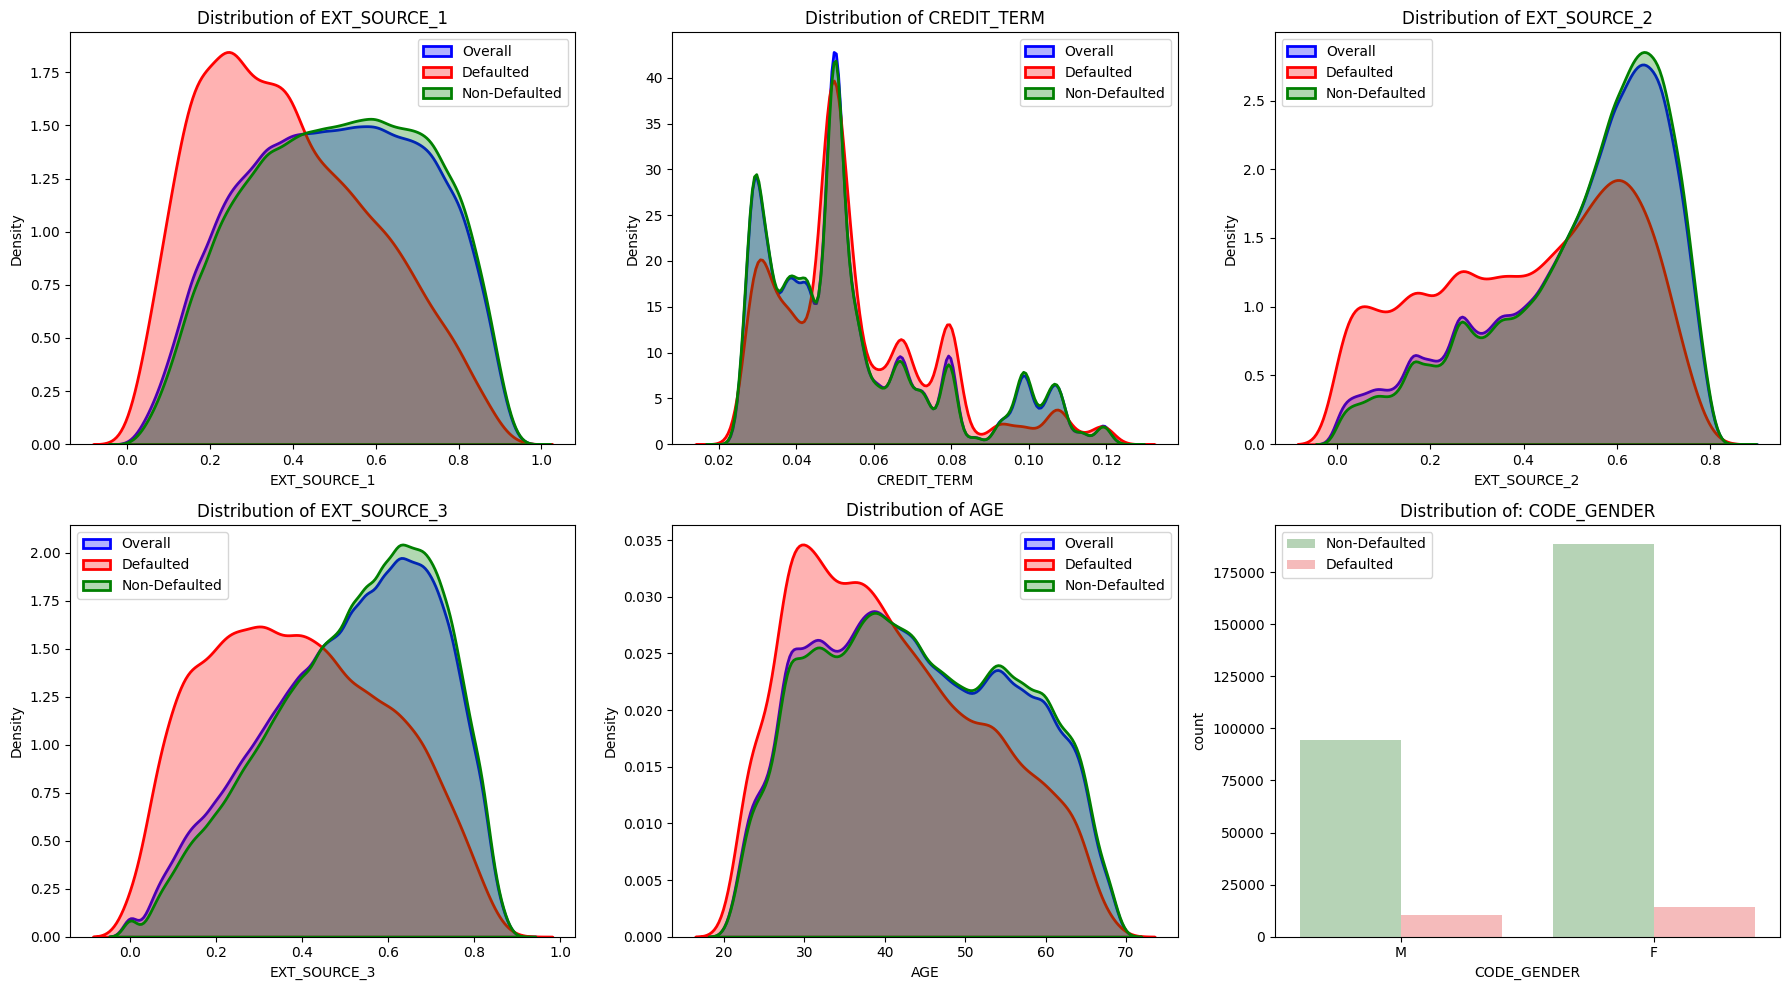

In [ ]:
# plot distributions
import_feat_cols = important_features.columns[:5]
fig, axes = plt.subplots(figsize=(18,10), nrows=2, ncols=3)
axes = axes.flatten()

for i, feature in enumerate(import_feat_cols):
    plot_distributions_on_axis(important_features, feature, axes[i])

gender_cleaned = important_features[important_features['CODE_GENDER'] != 'XNA']

sns.countplot(data=gender_cleaned, x='CODE_GENDER', hue='TARGET', ax=axes[5], palette={0: 'green', 1: 'red'}, alpha=0.3)
axes[5].set_title('Distribution of: CODE_GENDER')
axes[5].legend(labels=['Non-Defaulted', 'Defaulted'])

plt.tight_layout()
plt.show()
plt.close()

In [ ]:
important_features['CODE_GENDER'] = important_features['CODE_GENDER'].map({'M':0, 'F':1})

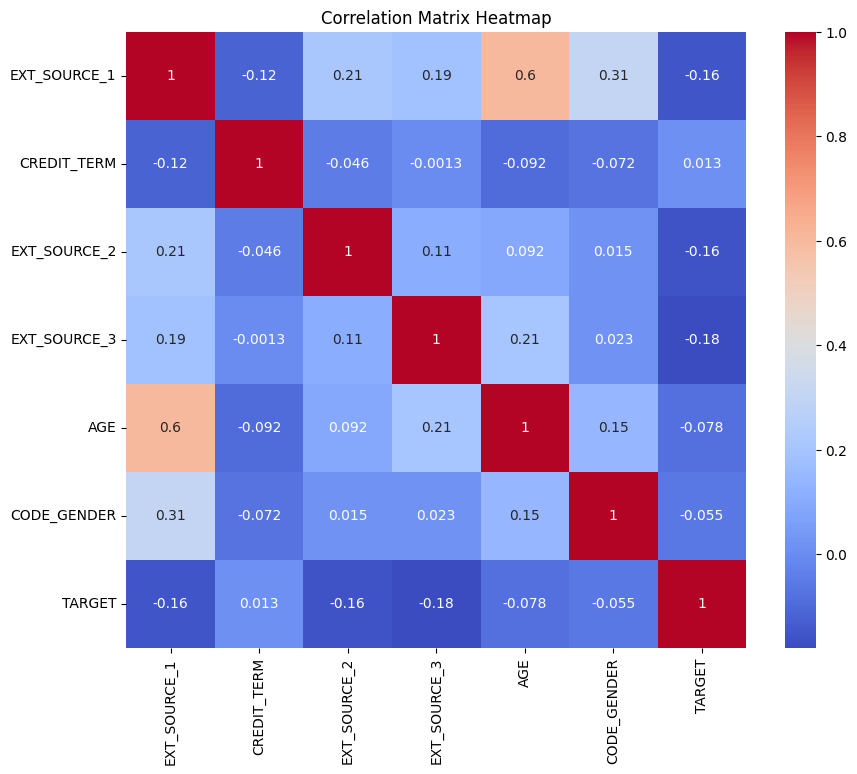

<Figure size 800x600 with 0 Axes>

In [ ]:
#plot correlations
corr = important_features.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix Heatmap')
plt.figure(figsize=(8, 6))
plt.show()
plt.close()

In [ ]:
# find class balance for TARGET
class_balance = important_features['TARGET'].value_counts()
print(class_balance)
class_balance/class_balance.sum()

TARGET
0    282686
1     24825
Name: count, dtype: int64


,count
TARGET,
0,0.919271
1,0.080729


We observe a major class imbalance with only 8% of the data defaulting on a loan.

## Fairness Metrics

In [ ]:
# define sensitive features and metric frame

sensitive_features_sex = test_X['CODE_GENDER_F'].replace({0: 'Men', 1: 'Women'})

metric_dict = {
    'accuracy': accuracy_score,
    'precision': precision_score,
    'recall': recall_score,
    'fnr': false_negative_rate,
    'fpr': false_positive_rate,
}

def calculate_metrics(y_pred, y_true, metric_dict, sensitive_features):
  metric_frame = MetricFrame( metrics=metric_dict,
                              y_true=y_true,
                              y_pred=y_pred,
                              sensitive_features=sensitive_features
                            )
  return metric_frame

In [ ]:
# Print results
model_metrics = calculate_metrics(predictions, test_Y, metric_dict, sensitive_features_sex)
print(model_metrics.overall)

print(model_metrics.by_group)

accuracy     0.726320
precision    0.184825
recall       0.690860
fnr          0.309140
fpr          0.270532
dtype: float64
               accuracy  precision    recall       fnr       fpr
CODE_GENDER_F                                                   
False          0.650991   0.192250  0.760254  0.239746  0.361370
True           0.765692   0.178686  0.638974  0.361026  0.224617


In [ ]:
# Calculate fairness metrics
fpr_diff = false_positive_rate_difference(test_Y, predictions, sensitive_features=sensitive_features_sex)
fnr_diff = false_negative_rate_difference(test_Y, predictions, sensitive_features=sensitive_features_sex)
sr_diff = selection_rate_difference(test_Y, predictions, sensitive_features=sensitive_features_sex)
dp_ratio = demographic_parity_ratio(test_Y, predictions, sensitive_features=sensitive_features_sex)
eo_ratio = equalized_odds_ratio(test_Y, predictions, sensitive_features=sensitive_features_sex)

model_fairness_metrics = pd.Series( data={'fpr difference': fpr_diff,
                                          'fnr difference': fnr_diff,
                                          'selection rate diff.': sr_diff,
                                          'demo. parity ratio': dp_ratio,
                                          'equalized odds ratio': eo_ratio,
                                          }
                                  )
print(model_fairness_metrics)

fpr difference          0.136753
fnr difference          0.121279
selection rate diff.    0.147855
demo. parity ratio      0.632120
equalized odds ratio    0.621571
dtype: float64


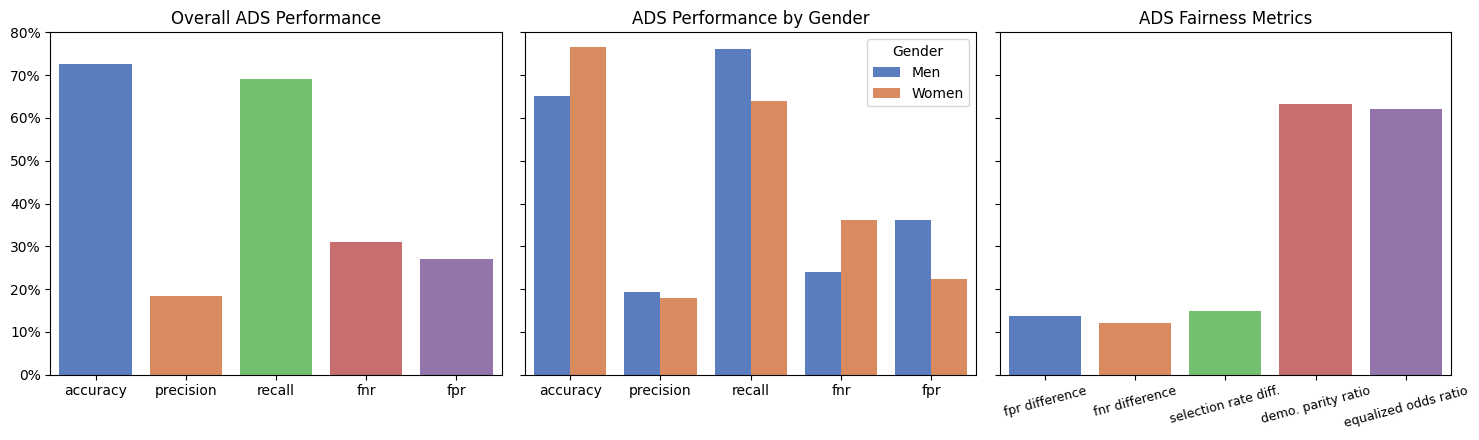

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 4.5), sharey=True)

# plot for overall results
overall_metrics = model_metrics.overall

sns.barplot(x=overall_metrics.index, y=overall_metrics.values, ax=axes[0], palette='muted')
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0, decimals=0))
axes[0].set_title('Overall ADS Performance')
axes[0].set_xlabel('')
axes[0].set_ylabel('')

# compare results by gender
metrics_df = model_metrics.by_group.reset_index()
metrics_df['CODE_GENDER_F'] = metrics_df['CODE_GENDER_F'].map({True: 'Women', False: 'Men'})
shaped_df = metrics_df.melt(id_vars='CODE_GENDER_F',
                            var_name='Metric',
                            value_name='Score')
shaped_df.rename(columns={'CODE_GENDER_F': 'Gender'}, inplace=True)

sns.barplot(data=shaped_df, x='Metric', y='Score', hue='Gender', palette='muted', ax=axes[1])
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0, decimals=0))
axes[1].set_title('ADS Performance by Gender')
axes[1].set_xlabel('')
axes[1].set_ylabel('')

# Plot fairness metrics
sns.barplot(x=model_fairness_metrics.index, y=model_fairness_metrics.values, ax=axes[2], palette='muted')
axes[2].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0, decimals=0))
axes[2].set_title('ADS Fairness Metrics')
axes[2].tick_params(axis='x', rotation=15, labelsize=9)
axes[2].set_xlabel('')
axes[2].set_ylabel('')

plt.setp(axes, ylim=(0, 0.8))
plt.tight_layout()
plt.savefig('metrics.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

## SHAP Anaylsis

In this section we will move beyond simple feature importance measured by splits in our trees to SHAP analysis. SHAP offers an understanding of how features pushed the model towards a certain decision when it comes to classifications.

In [ ]:
# initialize explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer(test_X)

female_mask = (test_X['CODE_GENDER_F'] == 1).values
male_mask = (test_X['CODE_GENDER_F'] == 0).values

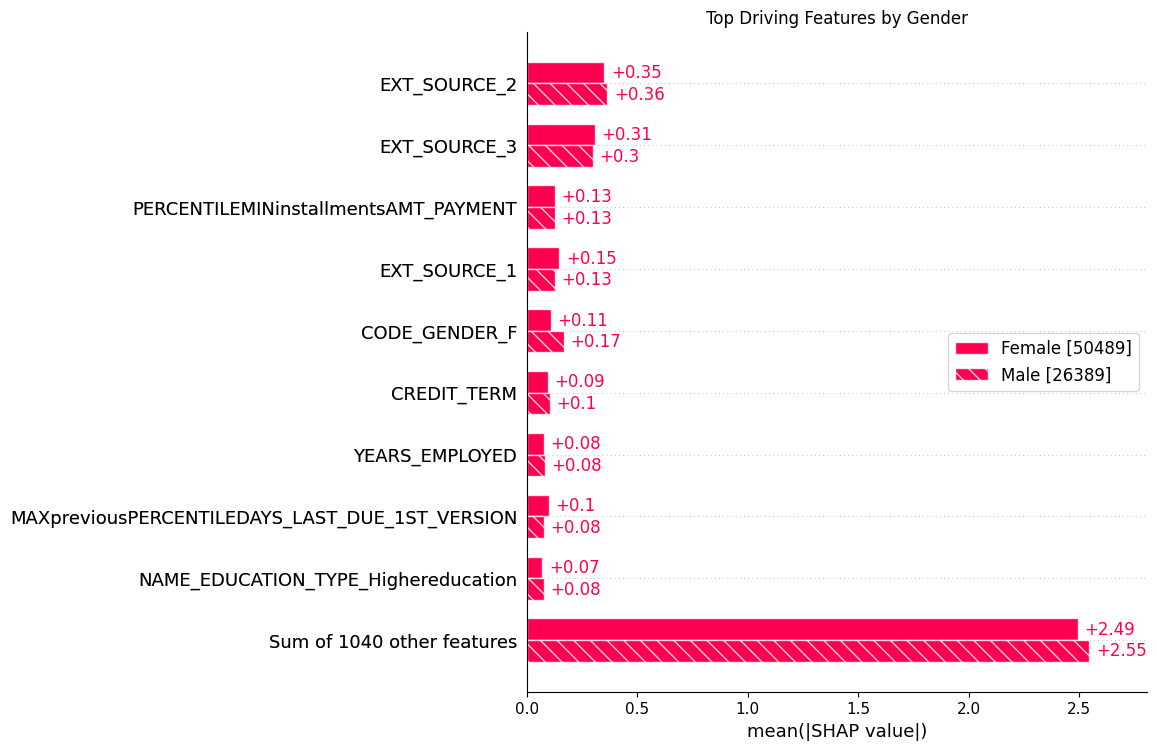

In [ ]:
# global bar plot

gender = {
    'Female': shap_values[female_mask],
    'Male': shap_values[male_mask]
}

shap.plots.bar(gender, max_display=10, show=False)

plt.title("Top Driving Features by Gender")
plt.show()

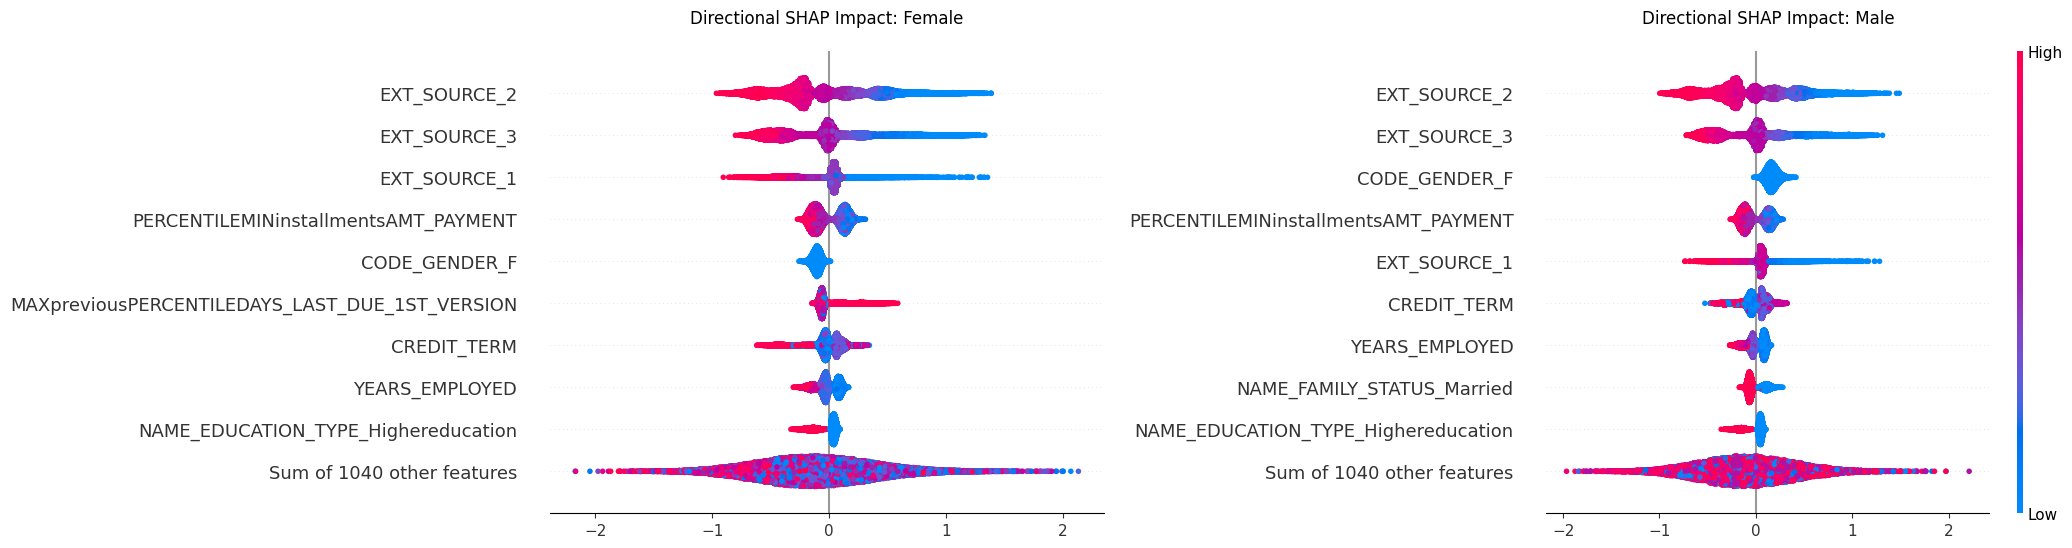

In [ ]:
# create beeswarm plot
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# females
plt.sca(axes[0])
shap.plots.beeswarm(shap_values[female_mask], max_display=10, show=False, color_bar=False, plot_size=None)
axes[0].set_title("Directional SHAP Impact: Female", pad=20)
#axes[0].tick_params(axis='both', labelsize=8)
axes[0].set_xlabel("")

# males
plt.sca(axes[1])
shap.plots.beeswarm(shap_values[male_mask], max_display=10, show=False, plot_size=None)
axes[1].set_title("Directional SHAP Impact: Male", pad=20)
#axes[1].tick_params(axis='both', labelsize=8)
axes[1].set_xlabel("")

cbar_ax = fig.axes[-1]
cbar_ax.set_ylabel("")
plt.subplots_adjust(wspace=0.8)
plt.show()
plt.close()

## Causal Discovery

In the following section we causally model our features. Given the computational constraints of our 1050 feature model, we will use shap values to find a subset of our most important features globally and establish our DAG. This method allows us to construct a DAG that is computational viable, while still maintaining a causal structure that is representative to our model.

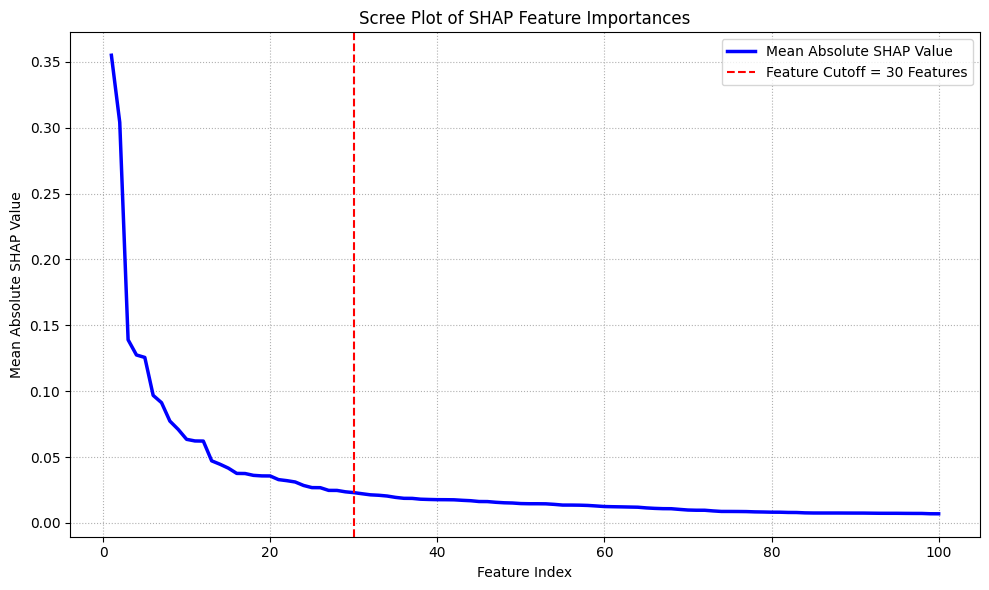

In [ ]:
# find top features with shap
mean_abs_shap = np.mean(np.abs(shap_values.values), axis=0)

shap_df = pd.DataFrame({
    'feature': train_X.columns,
    'importance': mean_abs_shap
})

shap_df = shap_df.sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.plot(range(1,101), shap_df['importance'].head(100), color='blue', linewidth=2.5, label='Mean Absolute SHAP Value')
plt.axvline(x=30, color='red', linestyle='--', linewidth=1.5, label='Feature Cutoff = 30 Features')
plt.ylabel('Mean Absolute SHAP Value')
plt.title('Scree Plot of SHAP Feature Importances')
plt.xlabel('Feature Index')
plt.ylabel('Mean Absolute SHAP Value')
plt.legend()
plt.grid(True, linestyle=':')
plt.tight_layout()
plt.show()
plt.close()

We observe that the true elbow of the scree plot is at the 20th most important feature. However, to ensure a conservative approach in our modeling, we will select the top 30 features. Since the 30th feature marks the point at which the slope stabilizes into an almost flat line, we can conclude that the remaining features add very little to the model's decision and are safer to leave out.

In [ ]:
# select top 30 features
t30_feats = shap_df['feature'].head(30).tolist()
print(t30_feats)

['EXT_SOURCE_2', 'EXT_SOURCE_3', 'EXT_SOURCE_1', 'CODE_GENDER_F', 'PERCENTILE(MIN(installments.AMT_PAYMENT))', 'CREDIT_TERM', 'MAX(previous.PERCENTILE(DAYS_LAST_DUE_1ST_VERSION))', 'YEARS_EMPLOYED', 'NAME_EDUCATION_TYPE_Higher education', 'NAME_FAMILY_STATUS_Married', 'AGE', 'AMT_ANNUITY', 'FLAG_OWN_CAR', 'MAX(previous.CNT_PAYMENT)', 'NAME_INCOME_TYPE_Working', 'MAX(bureau.DAYS_ENDDATE_FACT)', 'MEAN(cash.SK_DPD_DEF)', 'MEAN(bureau.AMT_CREDIT_SUM_DEBT)', 'MAX(bureau.AMT_CREDIT_MAX_OVERDUE)', 'MAX(previous.DAYS_LAST_DUE)', 'ANNUITY_INCOME_PERCENT', 'YEARS_ID_PUBLISH', 'SUM(previous.MEAN(credit.CNT_DRAWINGS_ATM_CURRENT))', 'DIFF(DEF_30_CNT_SOCIAL_CIRCLE)', 'PERCENTILE(MAX(cash.MONTHS_BALANCE))', 'MAX(previous.AMT_DOWN_PAYMENT)', 'MAX(bureau.PERCENTILE(DAYS_CREDIT_ENDDATE))', 'MIN(previous.SUM(cash.MONTHS_BALANCE))', 'MAX(bureau.DAYS_CREDIT)', 'MAX(previous.MEAN(installments.AMT_INSTALMENT))']


In [ ]:
t30_feats = [
    'EXT_SOURCE_2', 'EXT_SOURCE_3', 'EXT_SOURCE_1', 'CODE_GENDER_F',
    'PERCENTILEMINinstallmentsAMT_PAYMENT', 'CREDIT_TERM',
    'MAXpreviousPERCENTILEDAYS_LAST_DUE_1ST_VERSION', 'YEARS_EMPLOYED',
    'NAME_EDUCATION_TYPE_Highereducation', 'NAME_FAMILY_STATUS_Married',
    'AGE', 'AMT_ANNUITY', 'FLAG_OWN_CAR', 'MAXpreviousCNT_PAYMENT',
    'NAME_INCOME_TYPE_Working', 'MAXbureauDAYS_ENDDATE_FACT',
    'MEANcashSK_DPD_DEF', 'MEANbureauAMT_CREDIT_SUM_DEBT',
    'MAXbureauAMT_CREDIT_MAX_OVERDUE', 'MAXpreviousDAYS_LAST_DUE',
    'ANNUITY_INCOME_PERCENT', 'YEARS_ID_PUBLISH',
    'SUMpreviousMEANcreditCNT_DRAWINGS_ATM_CURRENT', 'DIFFDEF_30_CNT_SOCIAL_CIRCLE',
    'PERCENTILEMAXcashMONTHS_BALANCE', 'MAXpreviousAMT_DOWN_PAYMENT',
    'MAXbureauPERCENTILEDAYS_CREDIT_ENDDATE', 'MINpreviousSUMcashMONTHS_BALANCE',
    'MAXbureauDAYS_CREDIT', 'MAXpreviousMEANinstallmentsAMT_INSTALMENT'
]

# group features into tiers
dag = []

# aspects of an applicants identity that aren't influenced by anything else
t0_roots = ['CODE_GENDER_F', 'AGE']

# socioeconomic status
t1_ses = [
    'NAME_EDUCATION_TYPE_Highereducation', 'NAME_FAMILY_STATUS_Married',
    'YEARS_EMPLOYED', 'NAME_INCOME_TYPE_Working', 'DIFFDEF_30_CNT_SOCIAL_CIRCLE'
]

# current situation
t3_standing = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'FLAG_OWN_CAR']

# information related to the loan
t4_loan = ['CREDIT_TERM', 'AMT_ANNUITY', 'ANNUITY_INCOME_PERCENT']

# credit history
t2_credit = [
    feat for feat in t30_feats
    if any(sub in feat for sub in ['bureau', 'previous', 'cash', 'installments', 'credit'])
    and feat not in t3_standing and feat not in t1_ses and feat not in t4_loan
]


In [ ]:
# age and gender influence education, marriage, and employment
for root in t0_roots:
    for ses in t1_ses:
        dag.append((root, ses))

# important features in credit
core_credit = ['MAXpreviousCNT_PAYMENT', 'MEANbureauAMT_CREDIT_SUM_DEBT']

for ses in t1_ses:
    for credit in core_credit:
        dag.append((ses, credit))

    for standing in t3_standing:
        dag.append((ses, standing))

# age limits your credit history
for credit in t2_credit:
    dag.append(('AGE', credit))

# credit history impacts current situation
for credit in core_credit:
    for standing in t3_standing:
        dag.append((credit, standing))

# credit history and current situation impact the terms of the loan applicants apply for
for credit in core_credit:
    for loan in t4_loan:
        dag.append((credit, loan))

for standing in t3_standing:
    for loan in t4_loan:
        dag.append((standing, loan))

# the age of the id provided is limited by the age of the applicant
dag.append(('AGE', 'YEARS_ID_PUBLISH'))

# all features are used by the model for calculating probability of default
for feat in t30_feats:
    dag.append((feat, 'DEFAULT_PROB'))

print(f"Graph contains {len(dag)} causal edges.")

graph = nx.DiGraph()
graph.add_edges_from(dag)

Graph contains 112 causal edges.


## Average Treatment Effect of Gender

We will identify the ATE of Gender on model prediction probabilities in this section.

In [ ]:
df_dag = test_X.copy()
df_dag['DEFAULT_PROB'] = prediction_probabilities
df_dag = df_dag.sample(n=10_000, random_state=50)

gml_string = "\n".join(nx.generate_gml(graph))

ate_model = CausalModel(
    data=df_dag,
    treatment='CODE_GENDER_F',
    outcome='DEFAULT_PROB',
    graph=gml_string
)

# isolate backdoor paths
identified_estimand = ate_model.identify_effect(proceed_when_unidentifiable=True)
print(identified_estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
       d                         
────────────────(E[DEFAULT_PROB])
d[CODE_GENDER_F]                 
Estimand assumption 1, Unconfoundedness: If U→{CODE_GENDER_F} and U→DEFAULT_PROB then P(DEFAULT_PROB|CODE_GENDER_F,,U) = P(DEFAULT_PROB|CODE_GENDER_F,)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
       d                         
────────────────(E[DEFAULT_PROB])
d[CODE_GENDER_F]                 
Estimand assumption 1, Unconfoundedness: If U→{CODE_GENDER_F} and U→DEFAULT_PROB then P(DEFAULT_PROB|CODE_GENDER_F,,U) = P(DEFAULT_PROB|CODE_GENDER_F,)



In [ ]:
# estimate the effect
estimate = ate_model.estimate_effect(
    identified_estimand,
    method_name="backdoor.linear_regression",
)

print(f"The Causal ATE is: {estimate.value}")

The Causal ATE is: -0.07937961230461005


Our ATE of -0.0794 reveals that being a female causally reduces the model's predicted probability of default about  8%.

### Causal Refutation Tests
Next we will conduct a series of causal refutation tests on our estimated ATE to confirm our estimate is robust.

In [ ]:
res_placebo = ate_model.refute_estimate(
    identified_estimand,
    estimate,
    method_name="placebo_treatment_refuter",
    placebo_type="permute"
)
print(res_placebo)

Refute: Use a Placebo Treatment
Estimated effect:-0.07937961230461005
New effect:0.00041139382685972226
p value:0.98



In [ ]:
res_random=ate_model.refute_estimate(
    identified_estimand,
    estimate,
    method_name="random_common_cause",
)
print(res_random)

Refute: Add a random common cause
Estimated effect:-0.07937961230461005
New effect:-0.07937611980619044
p value:0.98



In [ ]:
res_subset=ate_model.refute_estimate(
    identified_estimand,
    estimate,
    method_name="data_subset_refuter",
    subset_fraction=0.9
)
print(res_subset)

Refute: Use a subset of data
Estimated effect:-0.07937961230461005
New effect:-0.0794008910844561
p value:0.98



Our three refutaion tests provided positive results for our ATE. This increases our confidence in our causal estimate.

## Counterfactual Fairness Analysis

We will now use our DAG to conduct counterfactual fairness analysis as laid out by Kusner et al. (2018). This will allow us to assess whether the model is individually fair and ask if an applicant's gender were different, how would model's classification change. We will calculate the counterfactual

In [ ]:
df_scm = test_X.copy()

for col in df_scm.columns:
    if df_scm[col].dtype == 'bool':
        df_scm[col] = df_scm[col].astype(int)

# remove model probabilites from the dag
cf_dag = [edge for edge in dag if edge[0] != 'DEFAULT_PROB' and edge[1] != 'DEFAULT_PROB']

# Initialize the SCM
causal_model = gcm.InvertibleStructuralCausalModel(nx.DiGraph(cf_dag))

for node in causal_model.graph.nodes:
    # Ridge Regression as default
    if len(list(causal_model.graph.predecessors(node))) > 0:
        causal_model.set_causal_mechanism(node, gcm.AdditiveNoiseModel(gcm.ml.create_hist_gradient_boost_regressor()))

    # Use the empirical distribution for root nodes
    else:
        causal_model.set_causal_mechanism(node, gcm.EmpiricalDistribution())

gcm.fit(causal_model, df_scm)

df_obs = df_scm[df_scm['CODE_GENDER_F'] == 0].copy()

df_cf = gcm.counterfactual_samples(
    causal_model,
    {'CODE_GENDER_F': lambda x: 1},
    observed_data=df_obs
)

model_features = model.feature_name_

def align_for_predict(df_input):
    # Create empty shell of 1049 columns
    full_df = pd.DataFrame(0, index=df_input.index, columns=model_features)
    # Fill only the 30 features in the dag
    for col in t30_feats:
        if col in full_df.columns:
            full_df[col] = df_input[col]
    return full_df

df_obs_ready = align_for_predict(df_obs)
df_cf_ready = align_for_predict(df_cf)

df_obs['preds'] = model.predict_proba(df_obs_ready)[:, 1]
df_cf['preds_cf'] = model.predict_proba(df_cf_ready)[:, 1]

obs_array = df_obs['preds'].values
cf_array = df_cf['preds_cf'].values

cf_score = (obs_array - cf_array).mean()

print(f"Counterfactual Fairness Score: {cf_score:.4f}")

Fitting causal mechanism of node YEARS_ID_PUBLISH: 100%|██████████| 30/30 [00:07<00:00,  4.19it/s]


Counterfactual Fairness Score: 0.1097


In [ ]:
def plot_counterfactual_fairness(
    df_obs: pd.DataFrame,
    df_cf: pd.DataFrame,
    mask: pd.Series,
    counterfactual_fairness: Union[int, float],
    legend_observed: str,
    legend_counterfactual: str,
    target: str,
    title: str,
) -> None:

    fig, ax = plt.subplots(figsize=(8, 5), nrows=1, ncols=1)

    ax.hist(
        df_obs[f"preds"][mask], bins=50, alpha=0.7, label=legend_observed, color="blue"
    )
    ax.hist(
        df_cf[f"preds_cf"][mask], bins=50, alpha=0.7, label=legend_counterfactual, color="orange"
    )

    ax.set_xlabel(target)
    ax.legend()
    ax.set_title(title)

    fig.suptitle(f"Counterfactual Fairness {round(counterfactual_fairness, 3)}")
    plt.axvline(x=0.5, linestyle="dashed", color='red')

    plt.tight_layout()
    plt.show()
    plt.close()

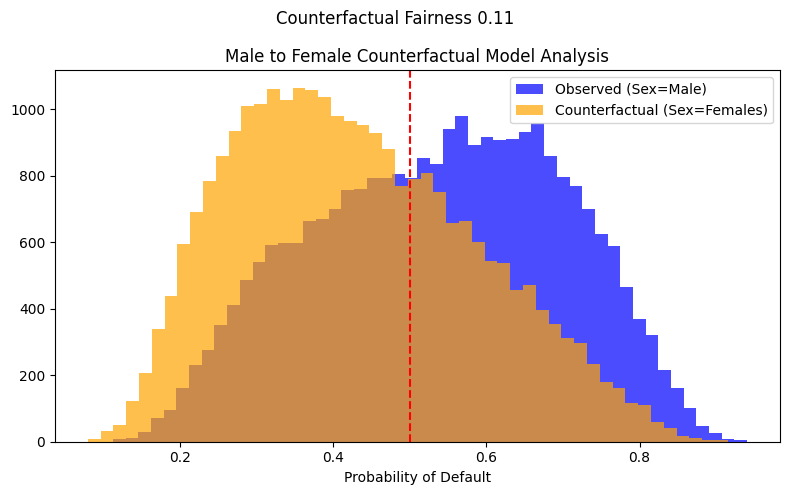

In [ ]:
#plot distributions
df_cf.index = df_obs.index
plot_mask = pd.Series([True] * len(df_obs), index=df_obs.index)

plot_counterfactual_fairness(
    df_obs=df_obs,
    df_cf=df_cf,
    mask=plot_mask,
    counterfactual_fairness=cf_score,
    legend_observed="Observed (Sex=Male)",
    legend_counterfactual="Counterfactual (Sex=Females)",
    target="Probability of Default",
    title="Male to Female Counterfactual Model Analysis"
)

## Measuring Epistemic Uncertainty

Next we will use Split Conformal Prediciton to measure predicitve uncertainty across protected groups. This method allows us to empirically measure whether model outputs are more confident for a certain gender.

In [ ]:
alpha = 0.05

def calculate_qhat(y_true, probs_1, alpha):
  n = len(y_true)
  probs_0 = 1 - probs_1

  true_class_probs = np.where(y_true == 1, probs_1, probs_0)

  # Calculate non-conformity scores
  scores = 1 - true_class_probs

  #calculate empirical quantile
  q_level = np.ceil((n + 1) * (1 - alpha)) / n
  q_hat = np.quantile(scores, q_level)
  return q_hat

# split test set in half for calibration data
hold_out_df = test_X.copy()
hold_out_df['TARGET'] = test_Y

df_scp_cal, df_scp_test = train_test_split(
    hold_out_df,
    test_size=0.5,
    random_state=50,
    stratify=hold_out_df['TARGET']
)

# split cal data by sex and get respective q_hats
cal_male = df_scp_cal[df_scp_cal['CODE_GENDER_F'] == 0]
cal_female = df_scp_cal[df_scp_cal['CODE_GENDER_F'] == 1]

cal_probs_male = model.predict_proba(cal_male.drop(columns=['TARGET']))[:, 1]
cal_probs_female = model.predict_proba(cal_female.drop(columns=['TARGET']))[:, 1]

q_hat_male = calculate_qhat(cal_male['TARGET'].values, cal_probs_male, alpha)
q_hat_female = calculate_qhat(cal_female['TARGET'].values, cal_probs_female, alpha)

print(f"Male Threshold (q_hat): {q_hat_male:.4f}")
print(f"Female Threshold (q_hat): {q_hat_female:.4f}")

Male Threshold (q_hat): 0.7769
Female Threshold (q_hat): 0.7354


In [ ]:
def prediction_sets(probs_1, q_hat):
  probs_0 = 1 - probs_1

  include_class_0 = probs_0 >= (1.0 - q_hat)
  include_class_1 = probs_1 >= (1.0 - q_hat)

  set_sizes = include_class_0.astype(int) + include_class_1.astype(int)

  return set_sizes

# split test data by sex and calculate conformal set sizes
test_male = df_scp_test[df_scp_test['CODE_GENDER_F'] == 0]
test_female = df_scp_test[df_scp_test['CODE_GENDER_F'] == 1]

test_probs_male = model.predict_proba(test_male.drop(columns=['TARGET']))[:, 1]
test_probs_female = model.predict_proba(test_female.drop(columns=['TARGET']))[:, 1]

male_set_sizes = prediction_sets(test_probs_male, q_hat_male)
female_set_sizes = prediction_sets(test_probs_female, q_hat_female)

print(f"Average Set Size for males: {np.mean(male_set_sizes):.3f}")
print(f"Average Set Size for females: {np.mean(female_set_sizes):.3f}")


Average Set Size for males: 1.742
Average Set Size for females: 1.535


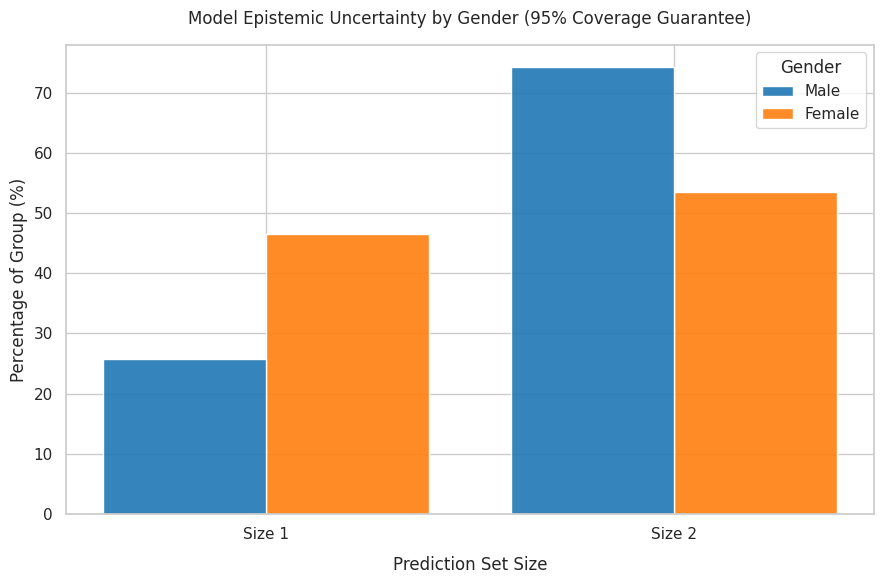

In [ ]:
# plot prediciton set sizes across sex
plot_df = pd.DataFrame({
    'Set Size': np.concatenate([male_set_sizes, female_set_sizes]),
    'Gender': ['Male'] * len(male_set_sizes) + ['Female'] * len(female_set_sizes)
})

plt.figure(figsize=(9, 6))
sns.set_theme(style="whitegrid")

sns.histplot(
    data=plot_df,
    x='Set Size',
    hue='Gender',
    multiple='dodge',
    stat='percent',
    common_norm=False,
    discrete=True,
    shrink=0.8,
    palette={'Male': '#1f77b4', 'Female': '#ff7f0e'},
    alpha=0.9
)

plt.title('Model Epistemic Uncertainty by Gender (95% Coverage Guarantee)', pad=15)
plt.xticks([1, 2], ['Size 1', 'Size 2'], fontsize=11)
plt.xlabel('Prediction Set Size', fontsize=12, labelpad=10)
plt.ylabel('Percentage of Group (%)', fontsize=12)

plt.tight_layout()
plt.show()
plt.close()